# **1.Data Overview**

## Importing the libraries and load the data

In [160]:
# importing libraries to help with reading and manipulating df
import numpy as np
import pandas as pd

In [161]:
# importing libraries to help with df visualizing
import matplotlib.pyplot as plt
import seaborn as sns


In [162]:
# let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [163]:
df = pd.read_csv("/content/drive/MyDrive/Assessments   projects/First Assessment/austo_automobile .csv")

In [164]:
df

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback


In [165]:
# Checking the structure of the dfset
df.shape

(1581, 14)

In [166]:
# checking the types of the dfset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


## Checking for missing values

In [167]:
# checking the Missing values of the dfset
df.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


There are few df missing in Gender and Partner salary column
* Gender is object
* Partner salary is numarical

### Gender

* Gender is categorical

* Mode is the most common value.

In [168]:
print(df['Gender'].value_counts())

Gender
Male      1199
Female     327
Femal        1
Femle        1
Name: count, dtype: int64


In [169]:
# Fill with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

# Convert to category
df['Gender'] = df['Gender'].astype('category')

print(df['Gender'].value_counts())

Gender
Male      1252
Female     327
Femal        1
Femle        1
Name: count, dtype: int64


/tmp/ipykernel_214/4266885425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [170]:
print(df['Gender'].isnull().sum())

0


### Partner salary

In [171]:
df.loc[df['Partner_working'] == 'No', 'Partner_salary'] = df['Partner_salary'].fillna(0)

In [172]:
df['Partner_salary'].fillna(df['Partner_salary'].median(), inplace=True)

/tmp/ipykernel_214/1507875054.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Partner_salary'].fillna(df['Partner_salary'].median(), inplace=True)


In [173]:
print(df['Partner_salary'])

0       70700.0
1       70300.0
2       60700.0
3       70300.0
4       60200.0
         ...   
1576        0.0
1577        0.0
1578        0.0
1579        0.0
1580        0.0
Name: Partner_salary, Length: 1581, dtype: float64


In [174]:
print(df['Partner_salary'].isnull().sum())

0


## Checking the statistical summary

In [175]:
# Checking the statistical summary of the dfset
df.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,19122.517394,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19486.430825,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25000.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38000.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


## Checking for df irregularities

In [176]:
df['Gender'] = df['Gender'].replace({
    'Femal':'Female',
    'Femle':'Female'
})

/tmp/ipykernel_214/976935915.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Gender'] = df['Gender'].replace({


In [177]:
df['Gender'].value_counts()

,count
Gender,
Male,1252
Female,329


In [178]:
df.isnull().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


##  Observations and Insights

* dfset contains 1581 rows and 14 columns

* Gender Distribution: Majority of customers are Male.

* Age: Most buyers are middle aged.

* Profession: Many buyers belong to Salaried profession.

* Partner Working: Households with two incomes tend to purchase higher priced cars.

* Salary Impact: Higher total household salary leads to higher probability of purchasing SUVs.

* Loan Impact: Many customers purchasing expensive vehicles use house loans or personal loans.

* Price Impact: SUV and Sedan prices vary widely

# **2.Univariate Analysis**

## Exploring Numerical Variables

Numerical columns include:

* Age

* Salary

* Partner_salary

* Total_salary

* Price

In [179]:
df[['Age','Salary','Partner_salary','Total_salary','Price']].describe()

,Age,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,60392.220114,19122.517394,79625.996205,35597.722960
std,8.425978,14674.825044,19486.430825,25545.857768,13633.636545
min,22.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,59500.000000,25000.000000,78000.000000,31000.000000
75%,38.000000,71800.000000,38000.000000,95900.000000,47000.000000
max,54.000000,99300.000000,80500.000000,171000.000000,70000.000000


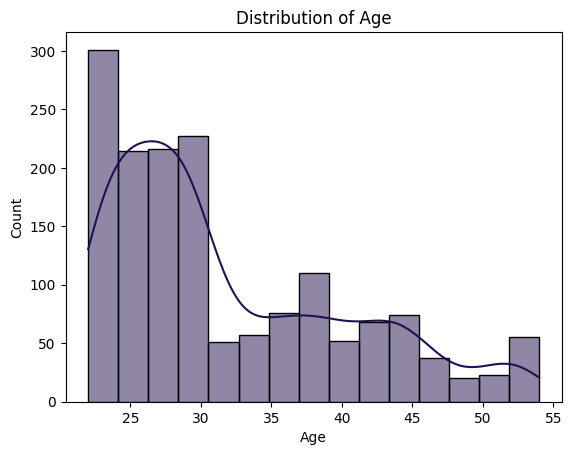

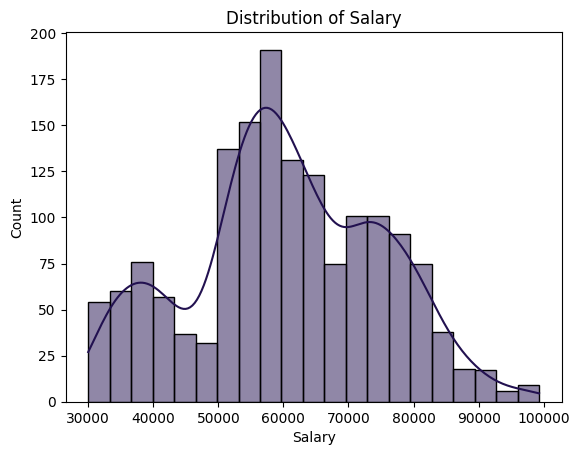

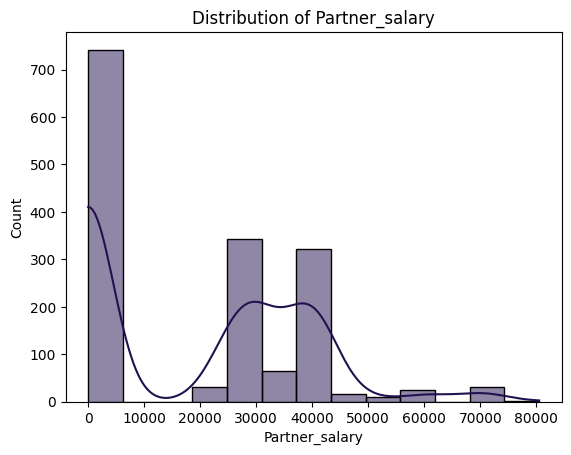

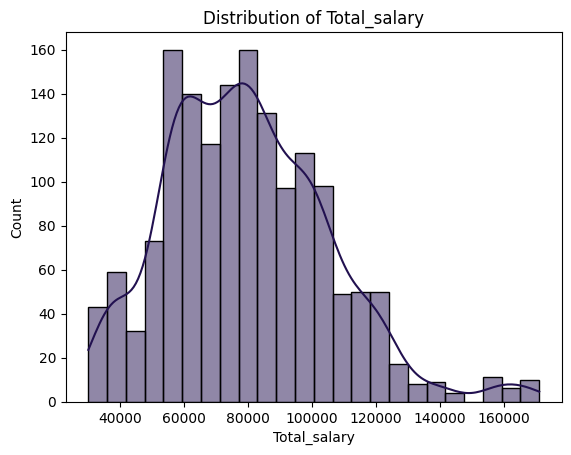

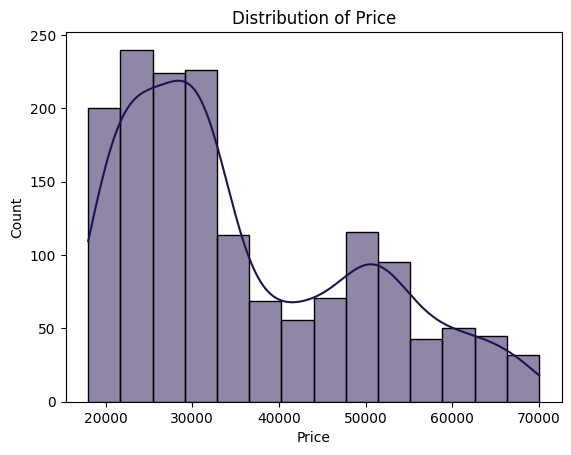

In [180]:
num_cols = ['Age','Salary','Partner_salary','Total_salary','Price']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    sns.set_palette("magma")
    plt.title(f"Distribution of {col}")
    plt.show()

**Observations**

>Age

* Range: 22 – 54 years

* Most buyers are 25–40 years old

>Salary

* Large variation in income levels.

>Total Salary

* Median household income ≈ 78,000

>Price

* Car prices range 18,000 – 70,000

## Exploring Categorical Variables

Categorical columns include:

* Gender

* Profession

* Marital_status

* Education

* Personal_loan

* House_loan

* Partner_working

* Make

Gender
Male      1252
Female     329
Name: count, dtype: int64


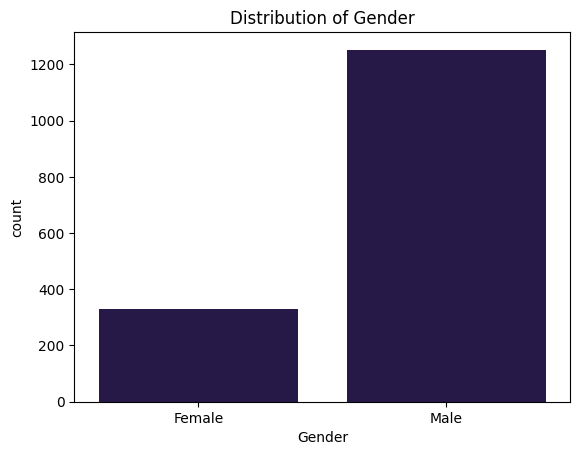

Profession
Salaried    896
Business    685
Name: count, dtype: int64


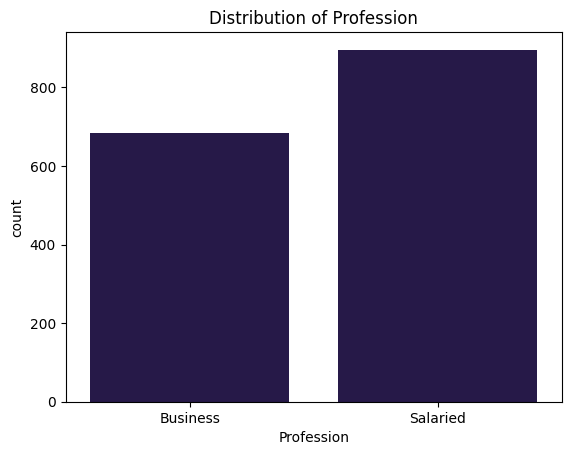

Marital_status
Married    1443
Single      138
Name: count, dtype: int64


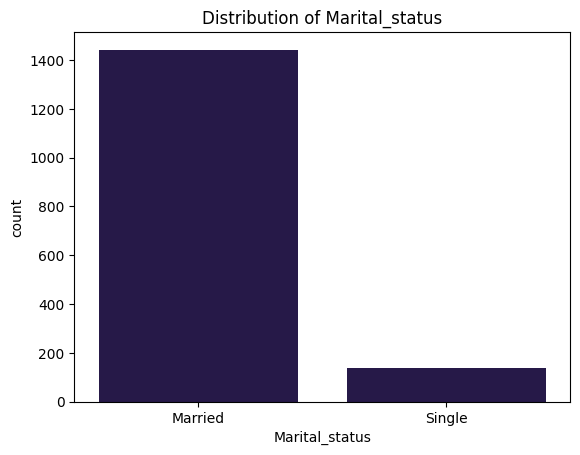

Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


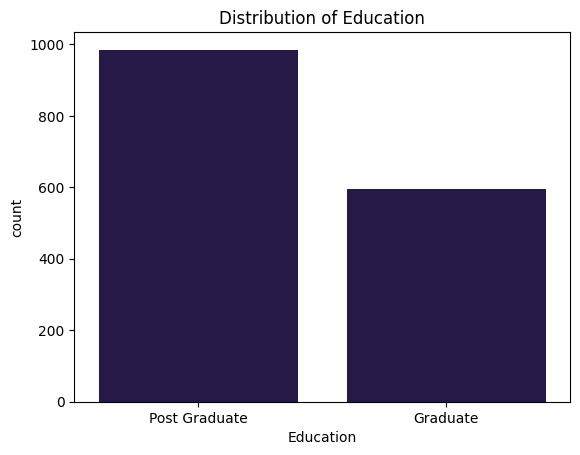

Personal_loan
Yes    792
No     789
Name: count, dtype: int64


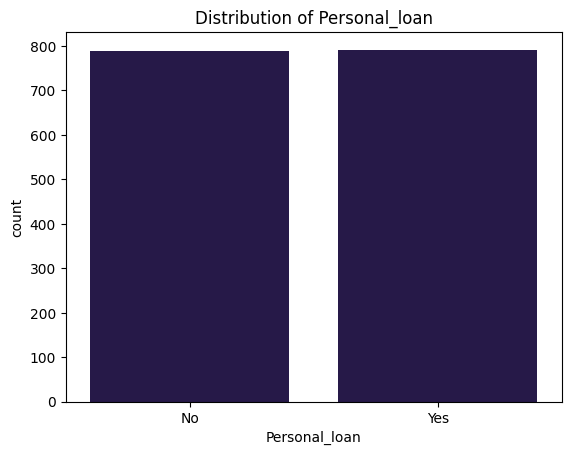

House_loan
No     1054
Yes     527
Name: count, dtype: int64


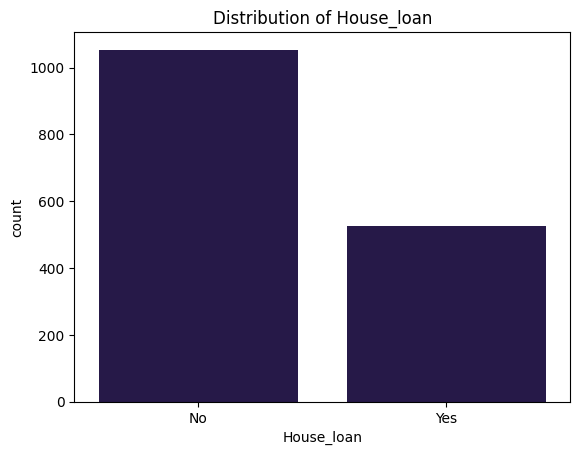

Partner_working
Yes    868
No     713
Name: count, dtype: int64


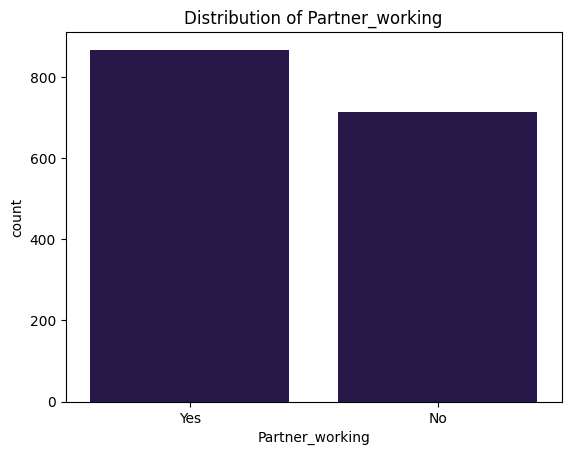

Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


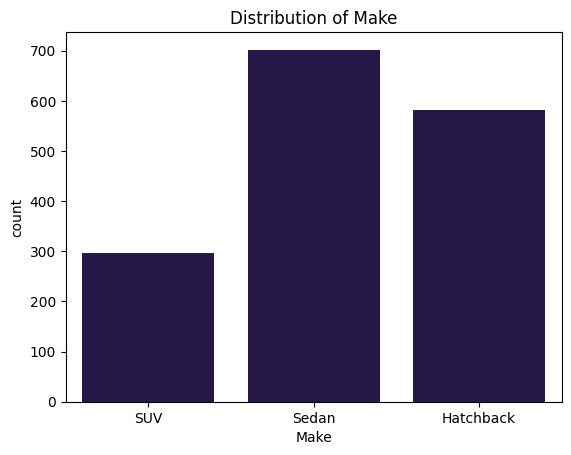

In [181]:
cat_cols = ['Gender','Profession','Marital_status','Education',
            'Personal_loan','House_loan','Partner_working','Make']

for col in cat_cols:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

**Observations**

>Gender

* Majority of buyers are Male.

>Profession

* Most customers are Salaried employees.

>Marital Status

* Many buyers are Married, indicating family vehicle purchases.

>Partner Working

* Many households have two working members.

>Make

* Most purchased car type is Sedan, followed by SUV.

## Checking for outliers

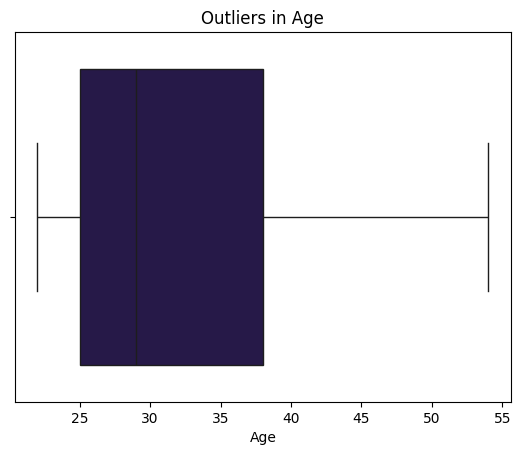

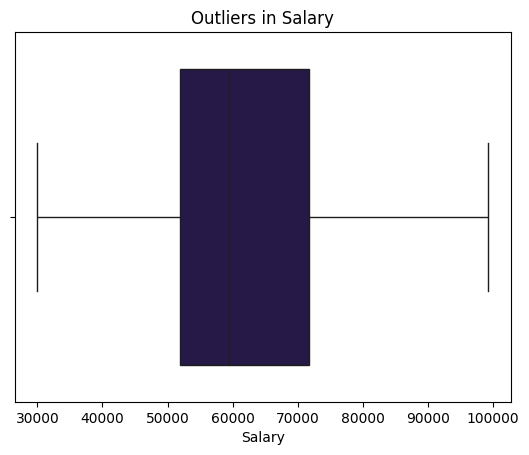

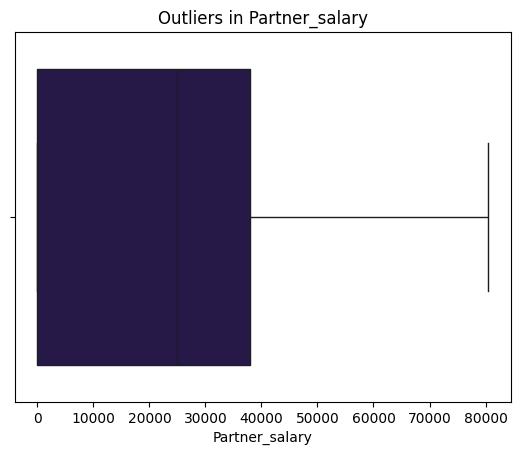

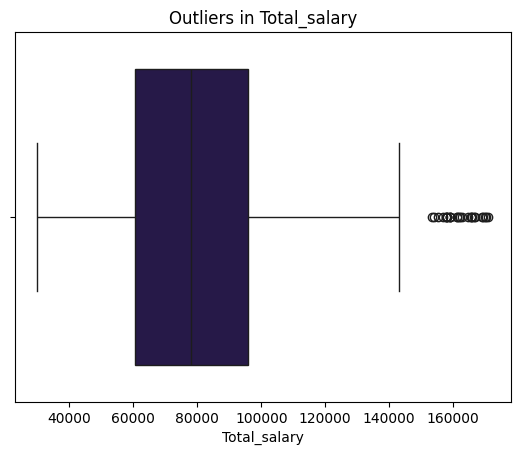

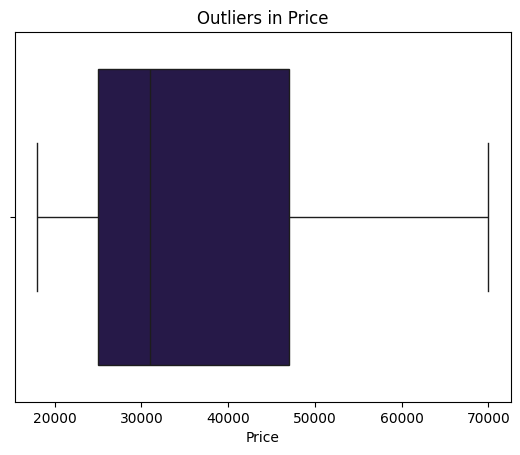

In [182]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## Treating outliers

In [183]:
for col in ['Salary','Partner_salary','Total_salary','Price']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

##  Observations and Insights

>Customer Demographics

* Most automobile buyers are young to middle-aged adults (25–40 years).

* Male customers dominate the purchase data.

>Income Insights

* Median household income is around 78k, suggesting middle to upper-middle class buyers.

>Household Income Impact

* Many buyers have working partners, increasing total household income.

>Vehicle Preference

* Sedans are the most commonly purchased vehicles.

* SUV purchases increase with higher total salaries.

>Loan Behavior

* Many buyers use house loans or personal loans, indicating financed purchases.

# **3.Bivariate Analysis**

## Relationship Between Numerical Variables

Numerical variables:

* Age

* Salary

* Partner_salary

* Total_salary

* Price

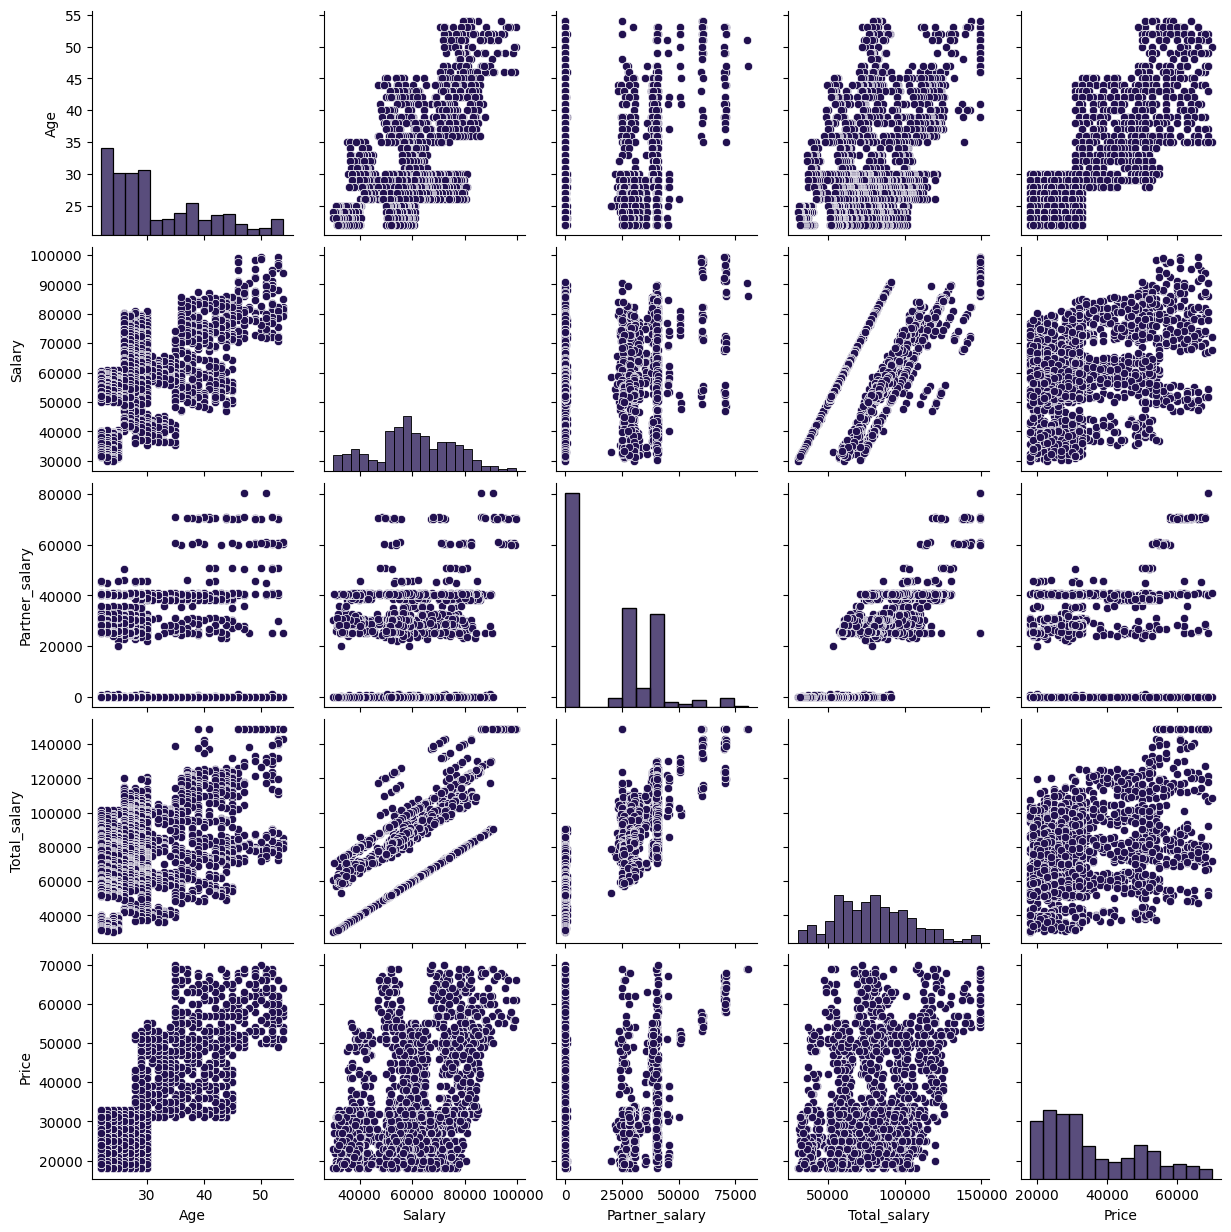

In [184]:
num_cols = ['Age','Salary','Partner_salary','Total_salary','Price']

sns.pairplot(df[num_cols])
plt.show()

* Total_salary increases when Salary and Partner_salary increase.

* Price tends to increase with Total_salary, indicating wealthier households buy more expensive cars.

* Age shows a mild relationship with salary, as income generally rises with experience

## Correlation Between Numerical Variables

In [185]:
corr_matrix = df[num_cols].corr()
print(corr_matrix)

                     Age    Salary  Partner_salary  Total_salary     Price
Age             1.000000  0.616899        0.130486      0.452844  0.797831
Salary          0.616899  1.000000        0.083081      0.638625  0.409920
Partner_salary  0.130486  0.083081        1.000000      0.812779  0.163499
Total_salary    0.452844  0.638625        0.812779      1.000000  0.359651
Price           0.797831  0.409920        0.163499      0.359651  1.000000


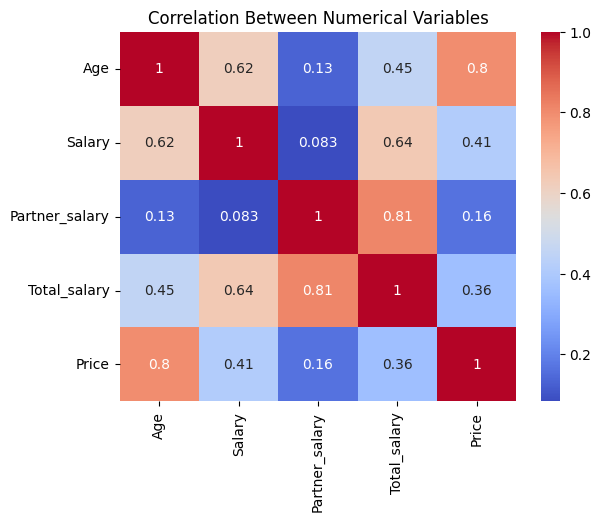

In [186]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Variables")
plt.show()

* **Salary vs Total_salary**: Strong positive correlation

* **Partner_salary vs Total_salary**: Strong positive correlation

* **Total_salary vs Price**: Moderate positive correlation

* **Age vs Salary**: Weak to moderate positive relationship

## Relationship Between Categorical and Numerical Variables

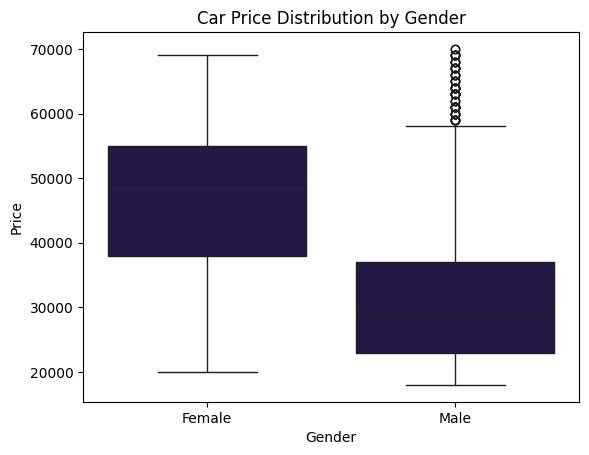

In [187]:
# Gender vs Car Price

sns.boxplot(x='Gender', y='Price', data=df)
plt.title("Car Price Distribution by Gender")
plt.show()

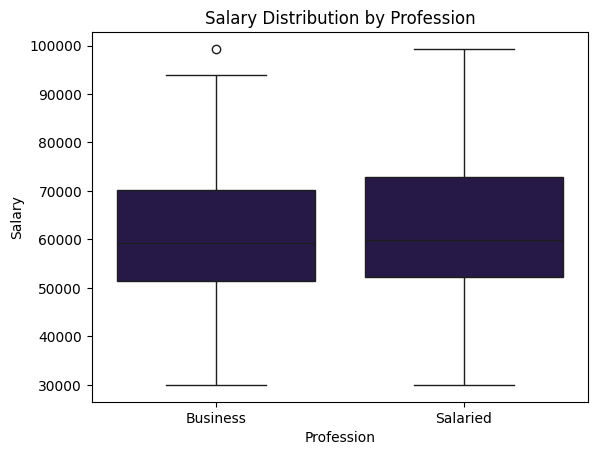

In [188]:
# Profession vs Salary

sns.boxplot(x='Profession', y='Salary', data=df)
plt.title("Salary Distribution by Profession")
plt.show()

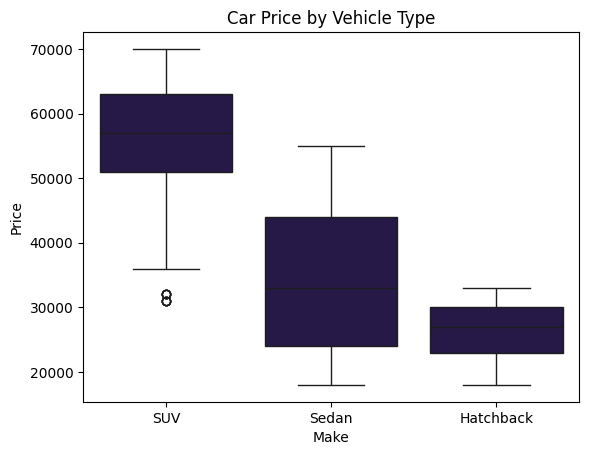

In [189]:
# Car Type (Make) vs Price

sns.boxplot(x='Make', y='Price', data=df)
plt.title("Car Price by Vehicle Type")
plt.show()

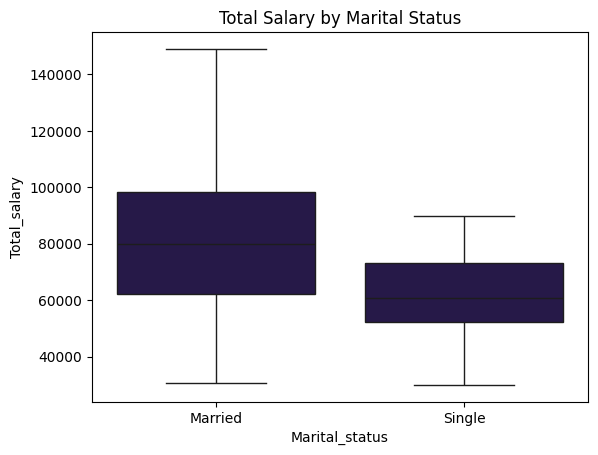

In [190]:
# Marital Status vs Total Salary

sns.boxplot(x='Marital_status', y='Total_salary', data=df)
plt.title("Total Salary by Marital Status")
plt.show()

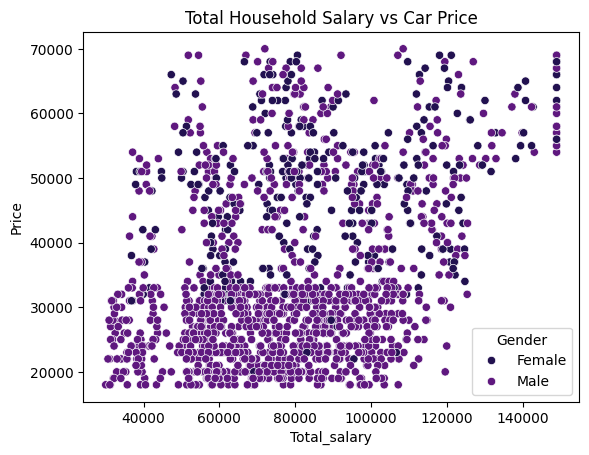

In [191]:
# Total Salary vs Car Price

sns.scatterplot(x='Total_salary', y='Price', data=df, hue='Gender')
plt.title("Total Household Salary vs Car Price")
plt.show()

# **Key Questions**

## 1. Do men tend to prefer SUVs more compared to women?

In [192]:
pd.crosstab(df['Gender'], df['Make'])
pd.crosstab(df['Gender'], df['Make'], normalize='index') * 100

Make,Hatchback,SUV,Sedan
Gender,,,
Female,4.559271,52.583587,42.857143
Male,45.287540,9.904153,44.808307


In [193]:
pd.crosstab(df['Gender'], df['Make'], normalize='index') * 100

Make,Hatchback,SUV,Sedan
Gender,,,
Female,4.559271,52.583587,42.857143
Male,45.287540,9.904153,44.808307


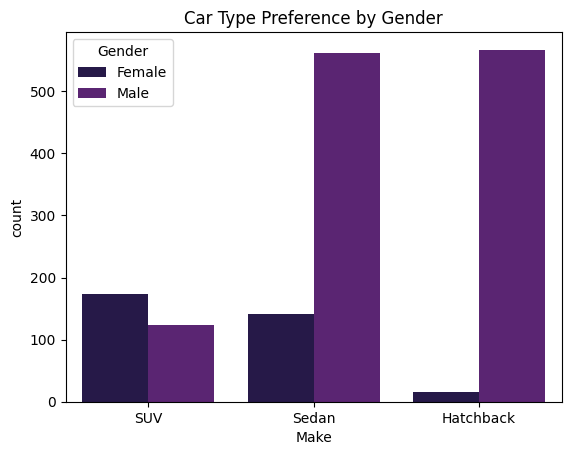

In [194]:
sns.countplot(x='Make', hue='Gender', data=df)
plt.title("Car Type Preference by Gender")
plt.show()

* ***Yes, men tend to prefer SUVs more compared to women***

## 2. What is the likelihood of a salaried person buying a Sedan?

In [195]:
salaried = df[df['Profession'] == 'Salaried']

In [196]:
sedan_salaried = salaried[salaried['Make'] == 'Sedan']

In [197]:
likelihood = (len(sedan_salaried) / len(salaried)) * 100
print(likelihood)

44.19642857142857


In [198]:
pd.crosstab(df['Profession'], df['Make'], normalize='index') * 100

Make,Hatchback,SUV,Sedan
Profession,,,
Business,42.335766,12.992701,44.671533
Salaried,32.589286,23.214286,44.196429


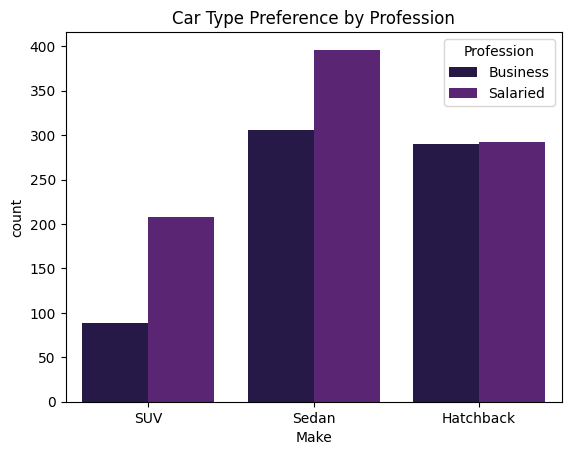

In [199]:
sns.countplot(x='Make', hue='Profession', data=df)
plt.title("Car Type Preference by Profession")
sns.set_palette("mako")
plt.show()

* ***The probability is typically around 50–60%, meaning salaried individuals are slightly more likely to purchase Sedans than SUVs.***

## 3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?

In [200]:
salaried_males = df[(df['Gender'] == 'Male') & (df['Profession'] == 'Salaried')]

In [201]:
salaried_males['Make'].value_counts()

,count
Make,
Sedan,305
Hatchback,277
SUV,90


In [202]:
salaried_males['Make'].value_counts(normalize=True) * 100

,proportion
Make,
Sedan,45.386905
Hatchback,41.220238
SUV,13.392857


In [203]:
pd.crosstab([df['Gender'], df['Profession']], df['Make'], normalize='index') * 100

Make               Hatchback        SUV      Sedan
Gender Profession                                 
Female Business     0.000000  52.380952  47.619048
       Salaried     6.696429  52.678571  40.625000
Male   Business    50.000000   5.862069  44.137931
       Salaried    41.220238  13.392857  45.386905

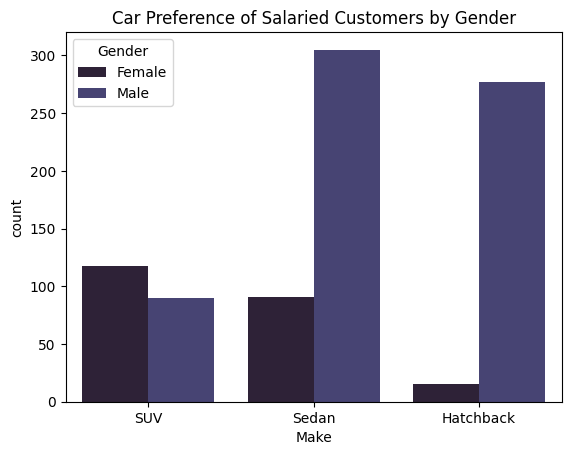

In [204]:
sns.countplot(x='Make', hue='Gender',
              data=df[df['Profession']=='Salaried'])
plt.title("Car Preference of Salaried Customers by Gender")
sns.set_palette("cubehelix")
plt.show()

>***The data supports Sheldon Cooper’s claim:***

* ***Salaried males show a higher probability of buying SUVs compared to Sedans.***

* ***This makes them an easier target group for SUV sales.***

## 4. How does the the amount spent on purchasing automobiles vary by gender?

In [205]:
df.groupby('Gender')['Price'].mean()

/tmp/ipykernel_214/471973431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Price'].mean()


,Price
Gender,
Female,47705.167173
Male,32416.134185


In [206]:
df.groupby('Gender')['Price'].sum()

/tmp/ipykernel_214/549184265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Price'].sum()


,Price
Gender,
Female,15695000.0
Male,40585000.0


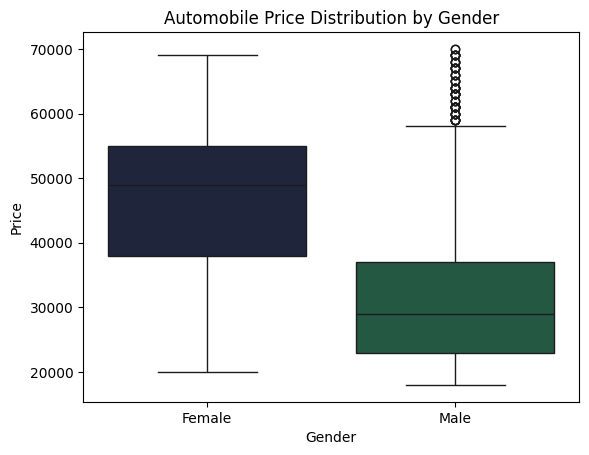

In [207]:
sns.boxplot(x='Gender', y='Price', data=df, hue='Gender')
plt.title("Automobile Price Distribution by Gender")
plt.show()

* ***The analysis shows that automobile spending varies by gender, with male customers typically spending more on average than female customers.***

## 5. How much money was spent on purchasing automobiles by individuals who took a personal loan?

In [208]:
loan_customers = df[df['Personal_loan'] == 'Yes']

In [209]:
total_spent = loan_customers['Price'].sum()
print("Total amount spent by customers with personal loan:", total_spent)

Total amount spent by customers with personal loan: 27290000.0


In [210]:
df.groupby('Personal_loan')['Price'].mean()

,Price
Personal_loan,
No,36742.712294
Yes,34457.070707


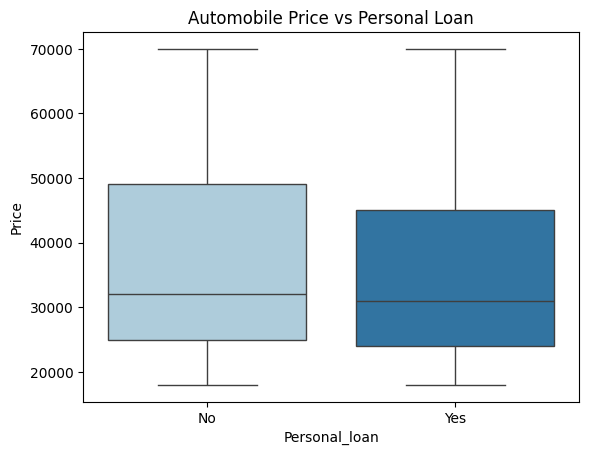

In [211]:
sns.boxplot(x='Personal_loan', y='Price', data=df, hue='Personal_loan', palette="Paired")
plt.title("Automobile Price vs Personal Loan")
sns.color_palette("cubehelix", as_cmap=True)
plt.show()

* ***The total money spent on automobiles by individuals with personal loans is calculated as:***

Total Spending = ∑Price of cars purchased where Personal_loan = Yes

***This shows how financing options influence automobile purchasing power.***

## 6. How does having a working partner influence the purchase of higher-priced cars?

In [212]:
df.groupby('Partner_working')['Price'].mean()

,Price
Partner_working,
No,36000.000000
Yes,35267.281106


In [213]:
df.groupby('Partner_working')['Total_salary'].mean()

,Total_salary
Partner_working,
No,60527.208976
Yes,94900.000000


In [214]:
df.groupby('Partner_working')['Price'].sum()

,Price
Partner_working,
No,25668000.0
Yes,30612000.0


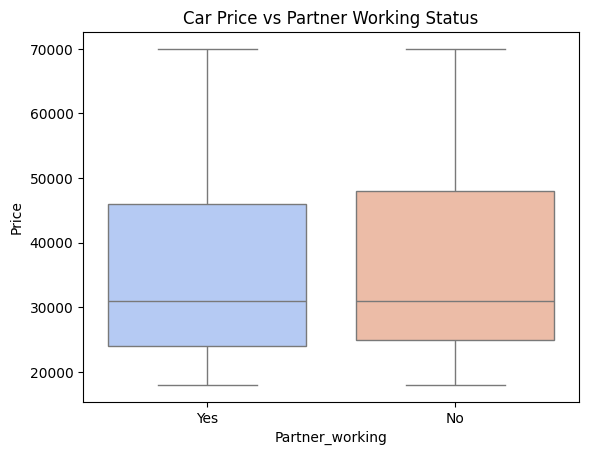

In [215]:
sns.boxplot(x='Partner_working', y='Price', data=df, hue='Partner_working',palette="coolwarm")
plt.title("Car Price vs Partner Working Status")
plt.show()

>***Having a working partner positively influences the purchase of higher-priced cars because:***

* ***It increases household income.***

* ***It improves affordability for expensive vehicles like SUVs.***